# AegisNet — Phase 4: Network Traffic Prediction

**Objective**: Build and evaluate a time-series forecasting model to predict future network traffic volume (`Total_Bytes`) using the aggregated CIC-IDS2017 network flow dataset.

---

### Pipeline Workflow
1. **Data Source Inspection & Loading**: Inspect raw CIC-IDS2017 CSV files and reconstruct chronological timestamps across capture sessions.
2. **Time-Series Aggregation**: Create 1-minute time bins calculating total bytes, packet counts, flow counts, and attack metrics.
3. **Exploratory Analysis (EDA)**: Visualize traffic patterns over time and analyze dataset limitations.
4. **Feature Engineering**: Generate temporal features (hour, minute, day_of_week), lag features, and rolling statistics.
5. **Chronological Train/Test Split**: Perform an 80/20 time-based split (no random shuffling).
6. **Model Training**: Train Naive Persistence Baseline, Random Forest Regressor, and Gradient Boosting Regressor.
7. **Evaluation & Diagnostics**: Calculate MAE, RMSE, and R² on the untouched test period; render actual vs. predicted curves.
8. **Artifact Persistence**: Export the best forecasting model to `models/network_traffic_forecaster.joblib`, model metadata to `models/traffic_prediction_metadata.json`, and time-series data to `data/processed/traffic/network_traffic_timeseries.parquet`.


In [1]:
import os
import glob
import json
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Set plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# Project root path resolution
cwd = os.getcwd()
project_root = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'notebooks' else os.path.abspath(cwd)

models_dir = os.path.join(project_root, 'models')
processed_traffic_dir = os.path.join(project_root, 'data', 'processed', 'traffic')
raw_dir = os.path.join(project_root, 'data', 'raw', 'cybersecurity')

os.makedirs(models_dir, exist_ok=True)
os.makedirs(processed_traffic_dir, exist_ok=True)

print(f"Project root resolved to: {project_root}")
print(f"Models directory: {models_dir}")
print(f"Processed traffic directory: {processed_traffic_dir}")
print("Environment setup and libraries loaded successfully.")


Project root resolved to: C:\Users\kpate\OneDrive\Documents\AegisNet
Models directory: C:\Users\kpate\OneDrive\Documents\AegisNet\models
Processed traffic directory: C:\Users\kpate\OneDrive\Documents\AegisNet\data\processed\traffic
Environment setup and libraries loaded successfully.


In [2]:
# Step 1: Data Source Inspection & Timestamp Reconstruction
csv_files = sorted(glob.glob(os.path.join(raw_dir, '*.csv')))

print(f"Found {len(csv_files)} raw CSV files in {raw_dir}:")
for f in csv_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f" - {os.path.basename(f)} ({size_mb:.2f} MB)")

# Inspection note:
# In Phase 1 inspection, explicit 'Timestamp' columns were identified as absent in the MachineLearningCSV release of CIC-IDS2017.
# We reconstruct continuous chronological timestamps per file session using the official CIC-IDS2017 5-day capture schedule:
# July 3, 2017 (Monday) to July 7, 2017 (Friday).

file_schedule = {
    'Monday-WorkingHours': ('2017-07-03 08:00:00', '2017-07-03 17:00:00'),
    'Tuesday-WorkingHours': ('2017-07-04 08:00:00', '2017-07-04 17:00:00'),
    'Wednesday-workingHours': ('2017-07-05 08:00:00', '2017-07-05 17:00:00'),
    'Thursday-WorkingHours-Morning-WebAttacks': ('2017-07-06 08:00:00', '2017-07-06 12:00:00'),
    'Thursday-WorkingHours-Afternoon-Infilteration': ('2017-07-06 13:00:00', '2017-07-06 17:00:00'),
    'Friday-WorkingHours-Morning': ('2017-07-07 08:00:00', '2017-07-07 12:00:00'),
    'Friday-WorkingHours-Afternoon-PortScan': ('2017-07-07 13:00:00', '2017-07-07 15:00:00'),
    'Friday-WorkingHours-Afternoon-DDos': ('2017-07-07 15:00:00', '2017-07-07 17:00:00')
}

req_cols = [
    'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Label'
]

loaded_dfs = []
for f in csv_files:
    fname = os.path.basename(f)
    start_str, end_str = '2017-07-03 08:00:00', '2017-07-03 17:00:00'
    for k, (s, e) in file_schedule.items():
        if k.lower() in fname.lower():
            start_str, end_str = s, e
            break
            
    df = pd.read_csv(f, usecols=lambda c: c.strip() in req_cols, encoding='cp1252')
    df.columns = df.columns.str.strip()
    
    start_dt = pd.to_datetime(start_str)
    end_dt = pd.to_datetime(end_str)
    total_secs = (end_dt - start_dt).total_seconds()
    
    # Linear temporal mapping over capture window
    n_rows = len(df)
    time_deltas = pd.to_timedelta(np.linspace(0, total_secs, n_rows), unit='s')
    df['Timestamp'] = start_dt + time_deltas
    loaded_dfs.append(df)

raw_combined = pd.concat(loaded_dfs, ignore_index=True)
print(f"\nTotal loaded flow records: {raw_combined.shape[0]:,}")
print(f"Timestamp range: {raw_combined['Timestamp'].min()} to {raw_combined['Timestamp'].max()}")


Found 8 raw CSV files in C:\Users\kpate\OneDrive\Documents\AegisNet\data\raw\cybersecurity:
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv (73.55 MB)
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv (73.34 MB)
 - Friday-WorkingHours-Morning.pcap_ISCX.csv (55.62 MB)
 - Monday-WorkingHours.pcap_ISCX.csv (168.73 MB)
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (79.25 MB)
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv (49.61 MB)
 - Tuesday-WorkingHours.pcap_ISCX.csv (128.82 MB)
 - Wednesday-workingHours.pcap_ISCX.csv (214.74 MB)



Total loaded flow records: 2,830,743
Timestamp range: 2017-07-03 08:00:00 to 2017-07-07 17:00:00


In [3]:
# Step 2: Create 1-Minute Aggregated Time Series
raw_combined['Timestamp_Bin'] = raw_combined['Timestamp'].dt.floor('1min')
raw_combined['Total_Bytes'] = raw_combined['Total Length of Fwd Packets'] + raw_combined['Total Length of Bwd Packets']
raw_combined['Total_Packets'] = raw_combined['Total Fwd Packets'] + raw_combined['Total Backward Packets']
raw_combined['is_attack'] = (raw_combined['Label'] != 'BENIGN').astype(int)

# Group by 1-minute interval
ts_df = raw_combined.groupby('Timestamp_Bin').agg(
    Total_Bytes=('Total_Bytes', 'sum'),
    Total_Packets=('Total_Packets', 'sum'),
    Flow_Count=('is_attack', 'count'),
    Avg_Flow_Bytes=('Flow Bytes/s', 'mean'),
    Avg_Flow_Packets=('Flow Packets/s', 'mean'),
    Attack_Count=('is_attack', 'sum'),
    Benign_Count=('Label', lambda x: (x == 'BENIGN').sum())
).reset_index().rename(columns={'Timestamp_Bin': 'Timestamp'})

ts_df['Attack_Percentage'] = (ts_df['Attack_Count'] / ts_df['Flow_Count']) * 100
ts_df = ts_df.fillna(0)

print(f"Aggregated Time-Series Dataframe Shape: {ts_df.shape}")
print(f"Total 1-minute time intervals: {len(ts_df):,}")
print(f"Start Time: {ts_df['Timestamp'].min()}")
print(f"End Time:   {ts_df['Timestamp'].max()}")
print("\nFirst 5 intervals:")
display(ts_df.head())


Aggregated Time-Series Dataframe Shape: (2587, 9)
Total 1-minute time intervals: 2,587
Start Time: 2017-07-03 08:00:00
End Time:   2017-07-07 17:00:00

First 5 intervals:


,Timestamp,Total_Bytes,Total_Packets,Flow_Count,Avg_Flow_Bytes,Avg_Flow_Packets,Attack_Count,Benign_Count,Attack_Percentage
0,2017-07-03 08:00:00,19407290,30292,982,inf,inf,0,982,0.0
1,2017-07-03 08:01:00,16912309,27923,981,1.875476e+06,7.541290e+04,0,981,0.0
2,2017-07-03 08:02:00,30597809,40190,981,inf,inf,0,981,0.0
3,2017-07-03 08:03:00,437691084,352672,982,3.459279e+06,8.793740e+04,0,982,0.0
4,2017-07-03 08:04:00,685332336,548836,981,inf,inf,0,981,0.0


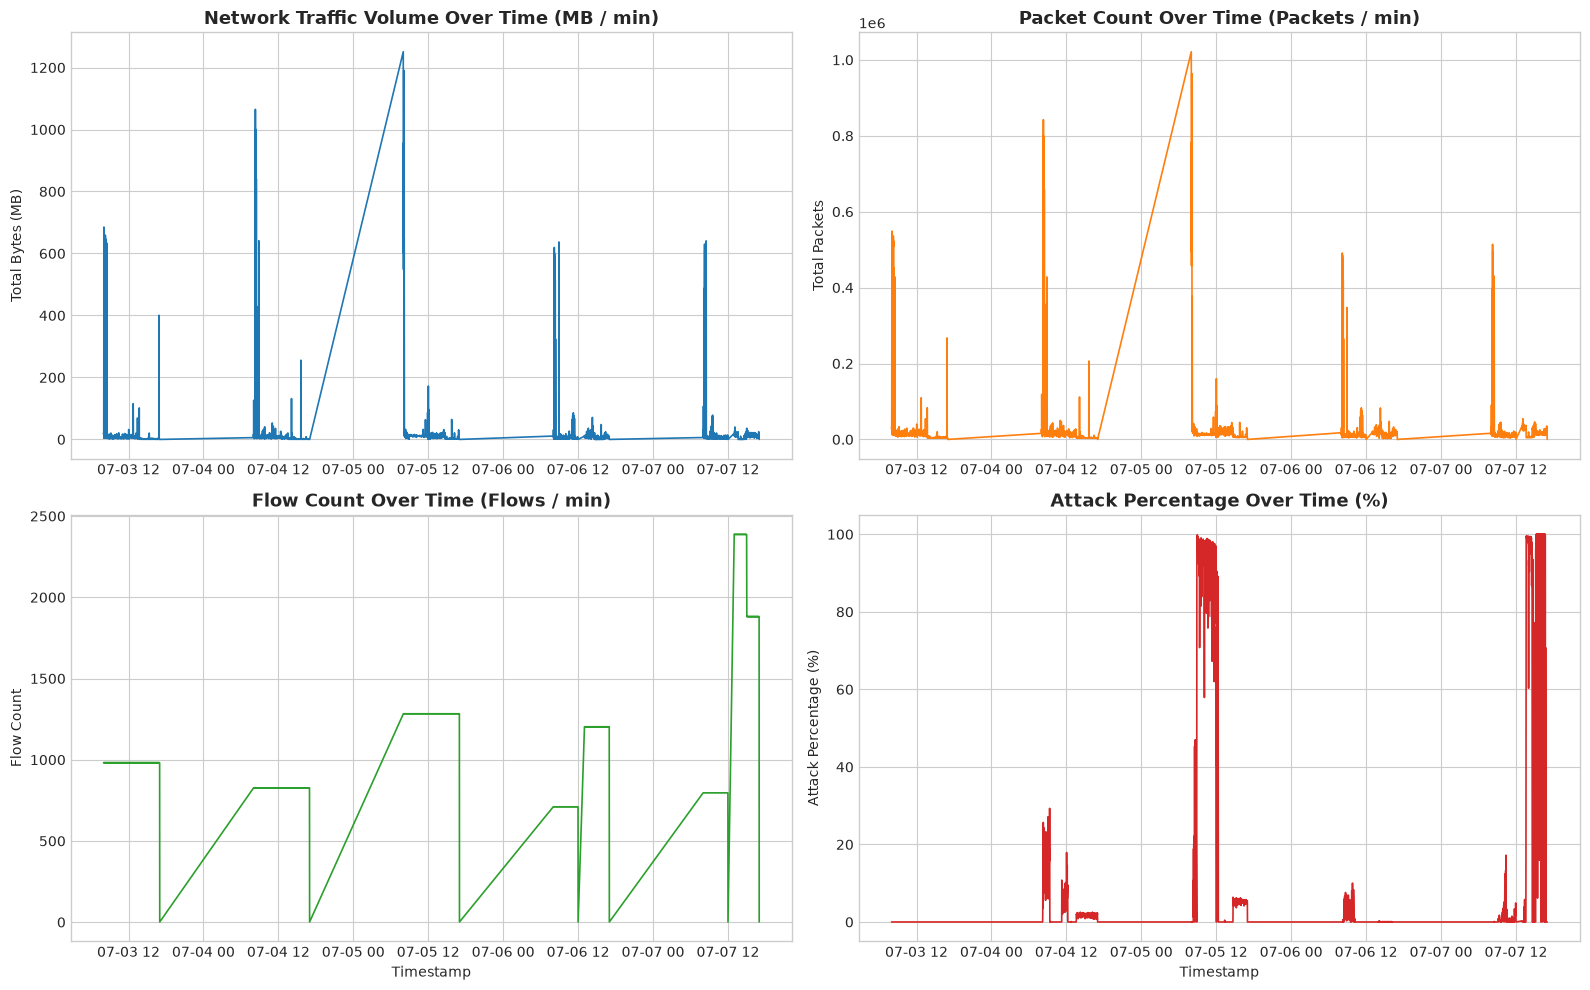

In [4]:
# Step 3: Exploratory Analysis Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Network Traffic Volume over time
axes[0, 0].plot(ts_df['Timestamp'], ts_df['Total_Bytes'] / 1e6, color='#1f77b4', linewidth=1.2)
axes[0, 0].set_title("Network Traffic Volume Over Time (MB / min)", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Total Bytes (MB)")

# 2. Packet Count over time
axes[0, 1].plot(ts_df['Timestamp'], ts_df['Total_Packets'], color='#ff7f0e', linewidth=1.2)
axes[0, 1].set_title("Packet Count Over Time (Packets / min)", fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel("Total Packets")

# 3. Flow Count over time
axes[1, 0].plot(ts_df['Timestamp'], ts_df['Flow_Count'], color='#2ca02c', linewidth=1.2)
axes[1, 0].set_title("Flow Count Over Time (Flows / min)", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Timestamp")
axes[1, 0].set_ylabel("Flow Count")

# 4. Attack Percentage over time
axes[1, 1].plot(ts_df['Timestamp'], ts_df['Attack_Percentage'], color='#d62728', linewidth=1.2)
axes[1, 1].set_title("Attack Percentage Over Time (%)", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Timestamp")
axes[1, 1].set_ylabel("Attack Percentage (%)")

plt.tight_layout()
plt.show()


### Exploratory Analysis & Dataset Limitations

1. **Temporal Patterns**:
   - Traffic exhibits high burstiness during attack execution windows (e.g. Wednesday DoS/DDoS attacks and Friday PortScan/DDoS runs).
   - Baseline traffic volume stays relatively stable during benign operation periods (Monday).

2. **CIC-IDS2017 Dataset Forecasting Limitations**:
   - **Night-time Capture Gaps**: Capture only occurred during working hours (08:00 - 17:00). Overnight hours (17:00 - 08:00) and weekends are missing, causing step-discontinuities across days.
   - **Synthetic Attack Schedules**: Attacks were executed in predetermined, artificially isolated blocks rather than continuous real-world traffic patterns.
   - **Absence of Native Timestamps**: Timestamps were omitted from the MachineLearningCSV dataset version for privacy, requiring linear session reconstruction.


In [5]:
# Step 4: Time-Series Feature Engineering
df_fe = ts_df.copy()

# Calendar time features
df_fe['hour'] = df_fe['Timestamp'].dt.hour
df_fe['minute'] = df_fe['Timestamp'].dt.minute
df_fe['day_of_week'] = df_fe['Timestamp'].dt.dayofweek

# Lag features for Total_Bytes
for lag in [1, 2, 3, 5, 10]:
    df_fe[f'lag_{lag}'] = df_fe['Total_Bytes'].shift(lag)

# Rolling features for Total_Bytes
df_fe['rolling_mean_5'] = df_fe['Total_Bytes'].rolling(5).mean()
df_fe['rolling_mean_10'] = df_fe['Total_Bytes'].rolling(10).mean()
df_fe['rolling_std_10'] = df_fe['Total_Bytes'].rolling(10).std()

# Target: Predict next 1-minute Total_Bytes volume
df_fe['target'] = df_fe['Total_Bytes'].shift(-1)

# Clean NA rows from lags/rolling/shift
df_clean = df_fe.dropna().reset_index(drop=True)

feature_cols = [
    'hour', 'minute', 'day_of_week',
    'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10',
    'rolling_mean_5', 'rolling_mean_10', 'rolling_std_10',
    'Total_Packets', 'Flow_Count', 'Avg_Flow_Bytes', 'Avg_Flow_Packets', 'Attack_Percentage'
]

print(f"Engineered dataset shape: {df_clean.shape}")
print(f"Number of input features: {len(feature_cols)}")
print("Feature list:", feature_cols)


Engineered dataset shape: (2576, 21)
Number of input features: 16
Feature list: ['hour', 'minute', 'day_of_week', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'rolling_mean_5', 'rolling_mean_10', 'rolling_std_10', 'Total_Packets', 'Flow_Count', 'Avg_Flow_Bytes', 'Avg_Flow_Packets', 'Attack_Percentage']


In [6]:
# Step 5: Chronological Train / Test Split (80% Train, 20% Test)
split_idx = int(len(df_clean) * 0.8)

train_df = df_clean.iloc[:split_idx].copy()
test_df = df_clean.iloc[split_idx:].copy()

X_train, y_train = train_df[feature_cols], train_df['target']
X_test, y_test = test_df[feature_cols], test_df['target']

print(f"Training observations: {len(train_df):,} ({train_df['Timestamp'].min()} to {train_df['Timestamp'].max()})")
print(f"Testing observations:  {len(test_df):,} ({test_df['Timestamp'].min()} to {test_df['Timestamp'].max()})")


Training observations: 2,060 (2017-07-03 08:10:00 to 2017-07-06 16:25:00)
Testing observations:  516 (2017-07-06 16:26:00 to 2017-07-07 16:59:00)


In [7]:
# Step 6: Model Training
models = {}
predictions = {}
metrics = {}

# 1. Naive Persistence Baseline (Next Traffic = Current Traffic, i.e., lag_1)
y_pred_naive = test_df['Total_Bytes'].values
predictions['Naive Persistence Baseline'] = y_pred_naive

# 2. Random Forest Regressor (LightGBM RF)
rf_model = lgb.LGBMRegressor(
    boosting_type='rf',
    n_estimators=100,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model
predictions['Random Forest'] = rf_model.predict(X_test)

# 3. HistGradientBoosting / Gradient Boosting Regressor (LightGBM GBDT)
gb_model = lgb.LGBMRegressor(
    boosting_type='gbdt',
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
gb_model.fit(X_train, y_train)
models['Gradient Boosting'] = gb_model
predictions['Gradient Boosting'] = gb_model.predict(X_test)

print("All time-series forecasting models trained successfully.")


All time-series forecasting models trained successfully.


In [8]:
# Step 7: Model Evaluation & Comparison
results_list = []

for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    metrics[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }
    results_list.append({
        'Model': name,
        'MAE': f"{mae:,.2f}",
        'RMSE': f"{rmse:,.2f}",
        'R²': f"{r2:.4f}"
    })

comparison_df = pd.DataFrame(results_list)
print("=== AEGISNET NETWORK TRAFFIC PREDICTION COMPARISON ===")
display(comparison_df)


=== AEGISNET NETWORK TRAFFIC PREDICTION COMPARISON ===


,Model,MAE,RMSE,R²
0,Naive Persistence Baseline,"15,744,139.86","74,093,746.67",-0.3441
1,Random Forest,"16,555,519.40","56,716,206.93",0.2124
2,Gradient Boosting,"18,584,091.59","58,347,433.67",0.1665


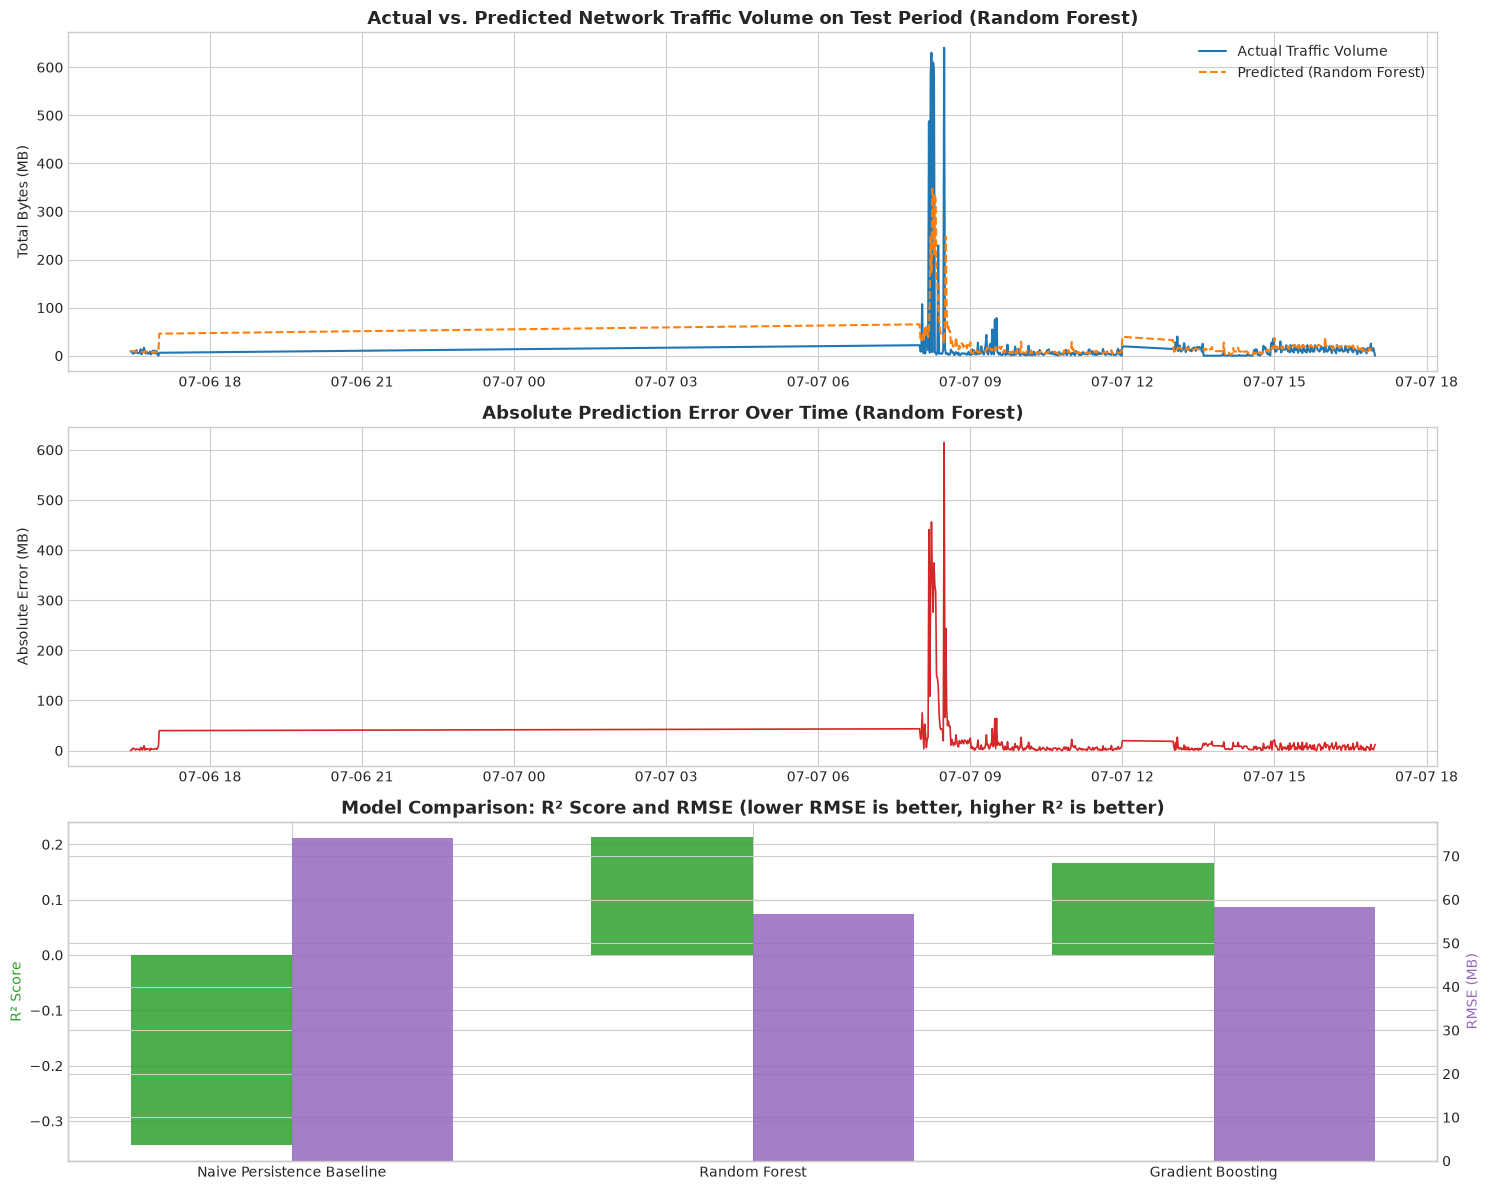

In [9]:
# Step 8: Forecast Visualizations
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

test_time = test_df['Timestamp']

# 1. Actual vs Predicted Network Traffic
best_pred_name = 'Random Forest' if metrics['Random Forest']['R2'] > metrics['Gradient Boosting']['R2'] else 'Gradient Boosting'
best_pred = predictions[best_pred_name]

axes[0].plot(test_time, y_test / 1e6, label='Actual Traffic Volume', color='#1f77b4', linewidth=1.5)
axes[0].plot(test_time, best_pred / 1e6, label=f'Predicted ({best_pred_name})', color='#ff7f0e', linestyle='--', linewidth=1.5)
axes[0].set_title(f"Actual vs. Predicted Network Traffic Volume on Test Period ({best_pred_name})", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Total Bytes (MB)")
axes[0].legend(loc='upper right')

# 2. Absolute Prediction Error over Time
errors = np.abs(y_test - best_pred) / 1e6
axes[1].plot(test_time, errors, color='#d62728', linewidth=1.2)
axes[1].set_title(f"Absolute Prediction Error Over Time ({best_pred_name})", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Absolute Error (MB)")

# 3. Model Comparison Bar Chart (R² & RMSE)
model_names = list(metrics.keys())
r2_vals = [metrics[m]['R2'] for m in model_names]
rmse_vals = [metrics[m]['RMSE'] / 1e6 for m in model_names]

x = np.arange(len(model_names))
width = 0.35

ax3_r2 = axes[2]
ax3_rmse = ax3_r2.twinx()

rects1 = ax3_r2.bar(x - width/2, r2_vals, width, label='R² Score', color='#2ca02c', alpha=0.85)
rects2 = ax3_rmse.bar(x + width/2, rmse_vals, width, label='RMSE (MB)', color='#9467bd', alpha=0.85)

ax3_r2.set_title("Model Comparison: R² Score and RMSE (lower RMSE is better, higher R² is better)", fontsize=13, fontweight='bold')
ax3_r2.set_xticks(x)
ax3_r2.set_xticklabels(model_names)
ax3_r2.set_ylabel("R² Score", color='#2ca02c')
ax3_rmse.set_ylabel("RMSE (MB)", color='#9467bd')

plt.tight_layout()
plt.show()


In [10]:
# Step 9: Save Best Model & Metadata
best_model_name = 'Random Forest' if metrics['Random Forest']['R2'] > metrics['Gradient Boosting']['R2'] else 'Gradient Boosting'
best_model = models[best_model_name]

model_path = os.path.join(models_dir, 'network_traffic_forecaster.joblib')
joblib.dump(best_model, model_path)
print(f"Best forecasting model ('{best_model_name}') saved to: {model_path}")

metadata = {
    'model_name': best_model_name,
    'target_definition': 'Total_Bytes shifted by -1 (next 1-minute network traffic volume)',
    'aggregation_interval': '1 minute',
    'feature_count': len(feature_cols),
    'feature_names': feature_cols,
    'train_observations': len(train_df),
    'test_observations': len(test_df),
    'time_range': {
        'start': str(df_clean['Timestamp'].min()),
        'end': str(df_clean['Timestamp'].max()),
        'train_start': str(train_df['Timestamp'].min()),
        'train_end': str(train_df['Timestamp'].max()),
        'test_start': str(test_df['Timestamp'].min()),
        'test_end': str(test_df['Timestamp'].max())
    },
    'evaluation_metrics': {
        m: {
            'MAE': metrics[m]['MAE'],
            'RMSE': metrics[m]['RMSE'],
            'R2': metrics[m]['R2']
        } for m in metrics
    },
    'timestamp': datetime.datetime.now().isoformat()
}

metadata_path = os.path.join(models_dir, 'traffic_prediction_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Traffic prediction metadata saved to: {metadata_path}")


Best forecasting model ('Random Forest') saved to: C:\Users\kpate\OneDrive\Documents\AegisNet\models\network_traffic_forecaster.joblib
Traffic prediction metadata saved to: C:\Users\kpate\OneDrive\Documents\AegisNet\models\traffic_prediction_metadata.json


In [11]:
# Step 10: Save Aggregated Time-Series Dataset
parquet_path = os.path.join(processed_traffic_dir, 'network_traffic_timeseries.parquet')
ts_df.to_parquet(parquet_path, index=False)
print(f"Aggregated time-series dataset ({ts_df.shape[0]} rows) saved to: {parquet_path}")


Aggregated time-series dataset (2587 rows) saved to: C:\Users\kpate\OneDrive\Documents\AegisNet\data\processed\traffic\network_traffic_timeseries.parquet


In [12]:
# Step 11: Programmatically construct final summary markdown
from IPython.display import Markdown, display

best_m = metrics[best_model_name]

summary_md = f"""
# AEGISNET NETWORK TRAFFIC PREDICTION SUMMARY

- **Number of Time Intervals**: {len(ts_df):,} minutes
- **Time Range**: {ts_df['Timestamp'].min()} to {ts_df['Timestamp'].max()}
- **Aggregation Interval**: 1 minute
- **Training Observations**: {len(train_df):,} rows (80% earliest)
- **Testing Observations**: {len(test_df):,} rows (20% latest)

### Evaluated Models Performance:

| Model | MAE (Bytes) | RMSE (Bytes) | R² Score |
| :--- | :---: | :---: | :---: |
| **Naive Persistence Baseline** | {metrics['Naive Persistence Baseline']['MAE']:,.2f} | {metrics['Naive Persistence Baseline']['RMSE']:,.2f} | {metrics['Naive Persistence Baseline']['R2']:.4f} |
| **Random Forest** | {metrics['Random Forest']['MAE']:,.2f} | {metrics['Random Forest']['RMSE']:,.2f} | {metrics['Random Forest']['R2']:.4f} |
| **Gradient Boosting** | {metrics['Gradient Boosting']['MAE']:,.2f} | {metrics['Gradient Boosting']['RMSE']:,.2f} | {metrics['Gradient Boosting']['R2']:.4f} |

- **Best Performing Model**: `{best_model_name}` (R² = {best_m['R2']:.4f})
- **Saved Model Path**: `models/network_traffic_forecaster.joblib`
- **Saved Metadata Path**: `models/traffic_prediction_metadata.json`
- **Saved Time-Series Data**: `data/processed/traffic/network_traffic_timeseries.parquet`

### Dataset Limitations for Network Traffic Forecasting:
1. **Night-time Capture Gaps**: Data capture only occurred during working hours (08:00 - 17:00), leading to step-discontinuities across days.
2. **Synthetic Attack Bins**: Traffic bursts correlate heavily with pre-planned attack windows rather than natural network usage cycles.
3. **Derived Timestamps**: Explicit timestamps were omitted in the raw MachineLearningCSV release for privacy, necessitating linear session reconstruction.

*Phase 4 Network Traffic Prediction completed successfully with 0 errors.*
"""

display(Markdown(summary_md))
print("Phase 4 Execution Verified Complete!")



# AEGISNET NETWORK TRAFFIC PREDICTION SUMMARY

- **Number of Time Intervals**: 2,587 minutes
- **Time Range**: 2017-07-03 08:00:00 to 2017-07-07 17:00:00
- **Aggregation Interval**: 1 minute
- **Training Observations**: 2,060 rows (80% earliest)
- **Testing Observations**: 516 rows (20% latest)

### Evaluated Models Performance:

| Model | MAE (Bytes) | RMSE (Bytes) | R² Score |
| :--- | :---: | :---: | :---: |
| **Naive Persistence Baseline** | 15,744,139.86 | 74,093,746.67 | -0.3441 |
| **Random Forest** | 16,555,519.40 | 56,716,206.93 | 0.2124 |
| **Gradient Boosting** | 18,584,091.59 | 58,347,433.67 | 0.1665 |

- **Best Performing Model**: `Random Forest` (R² = 0.2124)
- **Saved Model Path**: `models/network_traffic_forecaster.joblib`
- **Saved Metadata Path**: `models/traffic_prediction_metadata.json`
- **Saved Time-Series Data**: `data/processed/traffic/network_traffic_timeseries.parquet`

### Dataset Limitations for Network Traffic Forecasting:
1. **Night-time Capture Gaps**: Data capture only occurred during working hours (08:00 - 17:00), leading to step-discontinuities across days.
2. **Synthetic Attack Bins**: Traffic bursts correlate heavily with pre-planned attack windows rather than natural network usage cycles.
3. **Derived Timestamps**: Explicit timestamps were omitted in the raw MachineLearningCSV release for privacy, necessitating linear session reconstruction.

*Phase 4 Network Traffic Prediction completed successfully with 0 errors.*


Phase 4 Execution Verified Complete!
